In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_binned_cue, plot_dissimilarities
from SensoriMotorPrediction.force import calc_G_force
import PcmPy as pcm

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: data/atlases


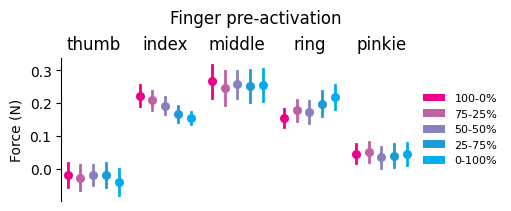

In [2]:
dat = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.trial.tsv'), sep='\t')
dat_cue_avg = dat.groupby(['sn', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, dat_cue_avg, y=f'{finger}0', x='cue', show_individuals=False)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Finger pre-activation')

plt.show()

force: tval=3.2576122221408705, pval=0.0031180970089363883


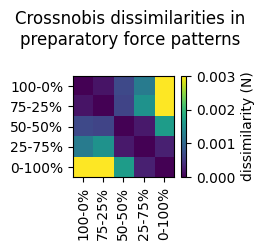

In [3]:
dat_block_cue = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
G_force, G_force_der = calc_G_force(dat_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)
vmin, vmax = 0, .003
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_dissimilarities(fig, ax, None, D_force, list(gl.regressor_mapping.keys())[:5],sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')

fig.suptitle('Crossnobis dissimilarities in\npreparatory force patterns')

fig.tight_layout()

plt.show()

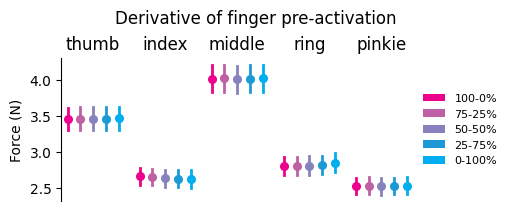

In [4]:
dat_cue_avg = dat.groupby(['sn', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, dat_cue_avg, y=f'{finger}_der0', x='cue', show_individuals=False)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Derivative of finger pre-activation')

plt.show()

force: tval=-0.32262402734735257, pval=0.623944996744814


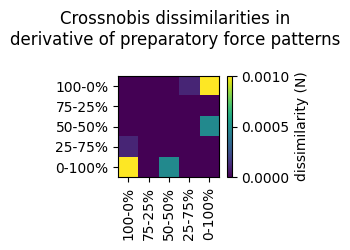

In [28]:
D_force_der = pcm.G_to_dist(G_force_der)
vmin, vmax = 0, .001
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_dissimilarities(fig, ax, None, D_force_der, list(gl.regressor_mapping.keys())[:5],sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')

fig.suptitle('Crossnobis dissimilarities in\nderivative of preparatory force patterns')

fig.tight_layout()

plt.show()

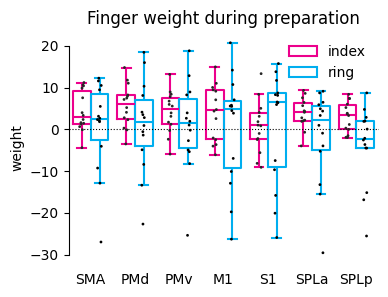

In [14]:
glm = 12
H = 'L'
atlas = 'ROI'
rois = gl.rois[atlas]
preact_weights = pd.read_csv(os.path.join(gl.baseDir, 'smp2', f'glm{glm}', 'ROI.preactivation_weights.tsv'), sep='\t')
preact_weights_melt = pd.melt(preact_weights, id_vars=['Hem', 'roi', 'sn'], value_vars=['index', 'ring'], value_name='weight', var_name='finger')
preact_weights_melt = preact_weights_melt[preact_weights_melt.Hem==H]
fig, ax = plt.subplots(figsize=(4, 3))
palette = [list(gl.colour_mapping.values())[0], list(gl.colour_mapping.values())[4]]
# sb.pointplot(data=preact_weights_melt, ax=ax, x='roi', y='weight', hue='finger', errorbar='se', palette=palette, ls='none', dodge=.4, lw=2)
sb.boxplot(data=preact_weights_melt, ax=ax, x='roi', y='weight', hue='finger', palette=palette, fill=False, showfliers=False)
sb.stripplot(data=preact_weights_melt, ax=ax, x='roi', y='weight', hue='finger', dodge=True, color='k', size=2, legend=False)
ax.axhline(0, color='k', ls=':', lw=.8)
ax.legend(frameon=False, loc='upper right',)
ax.set_xlabel('')
ax.tick_params(bottom=False)
ax.spines[['left']].set_bounds((-30, 20))
ax.spines[['bottom', 'right', 'top']].set_visible(False)

ax.set_title('Finger weight during preparation')

plt.show()

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=1.8842865350652842, pval=0.041040957018755986
PMd: tval=3.265034827303115, pval=0.0030738705348276555
PMv: tval=2.9469599082691293, pval=0.00566894426683502
M1: tval=3.3832462545926796, pval=0.0024487416991953027
S1: tval=4.1526114496004265, pval=0.0005678340178985813
SPLa: tval=3.322002721003307, pval=0.002754756206013128
SPLp: tval=3.9087054241031285, pval=0.0008981751836551068


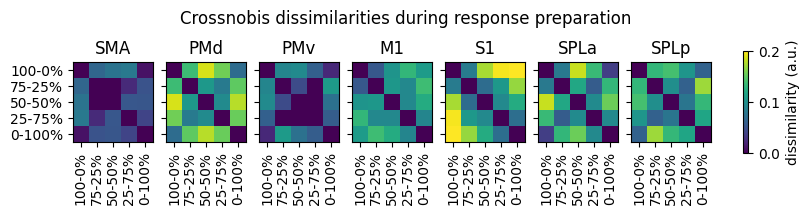

In [15]:
from SensoriMotorPrediction.vis import plot_dissimilarities

vmin, vmax = 0, .2

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.regr_out_preact_ols.glm12.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

T  dof alternative     p-val  \
roi  dataset                                                         
M1   original          T-test  2.446785   13     greater  0.014695   
     preactivation out T-test  1.764203   13     greater  0.050583   
PMd  original          T-test  3.697104   13     greater  0.001342   
     preactivation out T-test  2.123295   13     greater  0.026749   
PMv  original          T-test  1.618486   13     greater  0.064776   
     preactivation out T-test  0.751616   13     greater  0.232836   
S1   original          T-test  3.397400   13     greater  0.002383   
     preactivation out T-test  2.708273   13     greater  0.008955   
SMA  original          T-test  1.081856   13     greater  0.149488   
     preactivation out T-test  0.341115   13     greater  0.369234   
SPLa original          T-test  3.034924   13     greater  0.004787   
     preactivation out T-test  1.730185   13     greater  0.053625   
SPLp original          T-test  3.251405   13     greater  0.003156   
     preactivation out T-test  1.817720   13     greater  0.046109   

                                      CI95%   cohen-d    BF10     power  
roi  dataset                                                             
M1   original          T-test   [5.97, inf]  0.653931   4.765  0.749094  
     preactivation out T-test  [-0.06, inf]  0.471503   1.853  0.510643  
PMd  original          T-test   [5.15, inf]  0.988093  33.877  0.967881  
     preactivation out T-test   [0.75, inf]  0.567474   2.988  0.642856  
PMv  original          T-test  [-0.12, inf]  0.432559    1.55  0.455756  
     preactivation out T-test  [-0.63, inf]  0.200878   0.689  0.175691  
S1   original          T-test  [34.48, inf]  0.907993  20.947  0.941587  
     preactivation out T-test  [10.82, inf]  0.723816   7.074  0.820810  
SMA  original          T-test  [-0.58, inf]  0.289138   0.886  0.267945  
     preactivation out T-test  [-1.19, inf]  0.091167   0.568  0.093227  
SPLa original          T-test   [2.44, inf]  0.811117  11.768  0.890010  
     preactivation out T-test  [-0.08, inf]  0.462411   1.776  0.497811  
SPLp original          T-test   [3.25, inf]  0.868974  16.589  0.923736  
     preactivation out T-test   [0.05, inf]  0.485806   1.984  0.530801

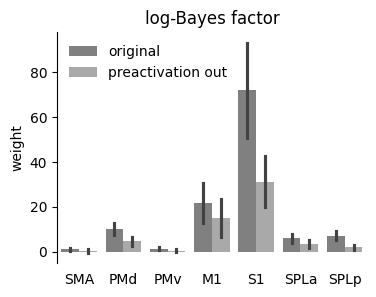

In [24]:
import pingouin as pg

df = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
df = df[(df.dataset.isin(['plan', 'regr_out_preact_ols'])) & (df.Hem==H) & (df.component=='expectation')]
df.dataset = df.dataset.map({'plan': 'original', 'regr_out_preact_ols': 'preactivation out'})
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='dataset', palette=['grey', 'darkgrey'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation')
results = df.groupby(['roi', 'dataset']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,dataset,original,preactivation out,True,True,1.788112,13.0,greater,0.048538,1.91,0.260478
PMd,0,dataset,original,preactivation out,True,True,2.536785,13.0,greater,0.012402,5.451,0.324426
PMv,0,dataset,original,preactivation out,True,True,2.422306,13.0,greater,0.015386,4.595,0.239808
S1,0,dataset,original,preactivation out,True,True,2.019204,13.0,greater,0.032289,2.589,0.534441
SMA,0,dataset,original,preactivation out,True,True,0.899650,13.0,greater,0.192334,0.764,0.165125
SPLa,0,dataset,original,preactivation out,True,True,1.742844,13.0,greater,0.052474,1.804,0.249488
SPLp,0,dataset,original,preactivation out,True,True,2.519505,13.0,greater,0.012814,5.311,0.469749


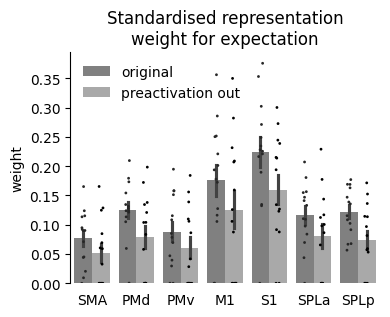

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight'] / df['noise'])
sb.barplot(ax=ax, data=df, x='roi', y='norm_weight', hue='dataset', palette=['grey', 'darkgrey'], errorbar='se')
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='dataset', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='dataset', subject='participant_id', alternative='greater'))
display(res)
plt.show()